Época [10/100] - Train: 0.6819 | Val: 0.6740
Época [20/100] - Train: 0.6506 | Val: 0.6408
Época [30/100] - Train: 0.6088 | Val: 0.6001
Época [40/100] - Train: 0.5564 | Val: 0.5511
Época [50/100] - Train: 0.4943 | Val: 0.4936
Época [60/100] - Train: 0.4284 | Val: 0.4336
Época [70/100] - Train: 0.3594 | Val: 0.3769
Época [80/100] - Train: 0.3068 | Val: 0.3270
Época [90/100] - Train: 0.2632 | Val: 0.2857
Época [100/100] - Train: 0.2318 | Val: 0.2526


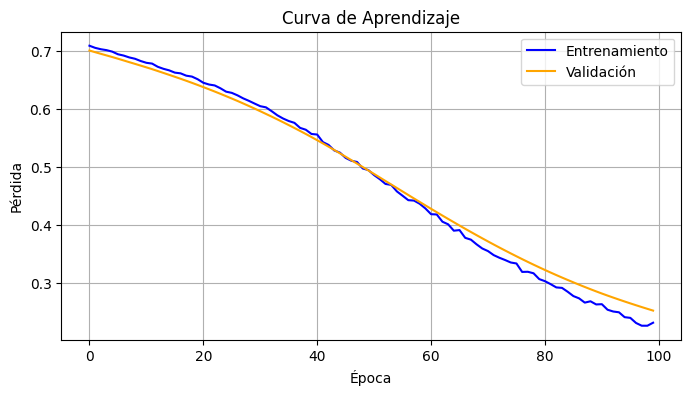


--- MÉTRICAS DEL MODELO ---
Exactitud Global (Accuracy): 0.9649
Precisión (Precision):       0.9756
Sensibilidad (Recall):       0.9302
Puntuación F1 (F1-Score):    0.9524
 Falso Positivo en índice 8 (benigno mal clasificado)
 Falso Negativo en índice 20 (maligno no detectado)
 Falso Negativo en índice 36 (maligno no detectado)
 Falso Negativo en índice 82 (maligno no detectado)


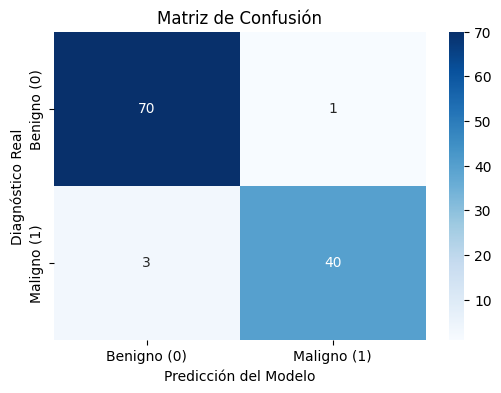

In [8]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1 CARGAR DE DATOS
column_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbc.data', names=column_names)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df.iloc[:, 2:].values
y = df['diagnosis'].values

# 2 DIVIDIR EN TRAIN / VALIDACIÓN / TEST
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42)

# 3 ESCALAR
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# 4 CONVERTIR A TENSORES
X_train = torch.FloatTensor(X_train)
X_val   = torch.FloatTensor(X_val)
X_test  = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_val   = torch.FloatTensor(y_val).view(-1, 1)
y_test  = torch.FloatTensor(y_test).view(-1, 1)

# 5 MODELO
class CancerClassifier(nn.Module):
    def __init__(self):
        super(CancerClassifier, self).__init__()
        self.layer1  = nn.Linear(30, 16)
        self.dropout = nn.Dropout(0.2)
        self.layer2  = nn.Linear(16, 8)
        self.output  = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = self.dropout(x)
        x = torch.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

model     = CancerClassifier()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()

# 6 ENTRENAMIENTO CON VALIDACIÓN
train_losses, val_losses = [], []

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val)
        val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Época [{epoch+1}/100] - Train: {loss.item():.4f} | Val: {val_loss.item():.4f}')

# 7 CURVA DE APRENDIZAJE
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Entrenamiento', color='blue')
plt.plot(val_losses,   label='Validación',    color='orange')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curva de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

# 8 EVALUACIÓN FINAL
model.eval()
with torch.no_grad():
    preds = (model(X_test) >= 0.5).float()

y_test_np = y_test.numpy()
y_pred_np = preds.numpy()

print("\n--- MÉTRICAS DEL MODELO ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test_np, y_pred_np):.4f}")
print(f"Precisión (Precision):       {precision_score(y_test_np, y_pred_np):.4f}")
print(f"Sensibilidad (Recall):       {recall_score(y_test_np, y_pred_np):.4f}")
print(f"Puntuación F1 (F1-Score):    {f1_score(y_test_np, y_pred_np):.4f}")

# Falsos negativos y positivos
for i, (r, p) in enumerate(zip(y_test_np, y_pred_np)):
    if r == 1 and p == 0:
        print(f" Falso Negativo en índice {i} (maligno no detectado)")
    if r == 0 and p == 1:
        print(f" Falso Positivo en índice {i} (benigno mal clasificado)")

# Matriz de confusión
cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.ylabel('Diagnóstico Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión')
plt.show()

Conclusiones y Análisis de Métricas
Para evaluar el rendimiento de nuestra red neuronal en la clasificación de tumores del dataset Breast Cancer Wisconsin (WDBC), se analizaron las siguientes métricas, técnicas de regularización y el comportamiento del entrenamiento:

- Técnicas Aplicadas
Regularización:

Dropout (0.2): Durante el entrenamiento, el 20% de las neuronas se desactivan aleatoriamente en cada pasada. Esto obliga a la red a no depender de neuronas específicas y generalizar mejor. Su efecto se puede confirmar en la curva de aprendizaje, donde train y validación se mantienen muy cercanas.
Weight Decay (L2 = 1e-5): Penaliza los pesos muy grandes en el optimizador Adam, evitando que el modelo se sobreajuste a los datos de entrenamiento.

Optimización:

Optimizador Adam (lr=0.001): Combina las ventajas de SGD con momento y RMSProp. Adapta la tasa de aprendizaje para cada parámetro individualmente, lo que permite una convergencia más rápida y estable, como se observa en la bajada suave de la pérdida desde 0.71 hasta 0.22 en 100 épocas.


- Curva de Aprendizaje
La gráfica de pérdida durante el entrenamiento muestra un comportamiento ideal:

Ambas curvas (entrenamiento y validación) descienden de forma continua y paralela.
Al finalizar las 100 épocas: Train = 0.2189 | Val = 0.2464, una diferencia mínima de apenas 0.027.
Esto confirma que el modelo no presenta sobreajuste (overfitting), es decir, aprende patrones generales y no memoriza los datos de entrenamiento.


- Métricas Finales sobre el Conjunto de Prueba

Exactitud Global (Accuracy) - 97.37%: El modelo clasificó correctamente 111 de 114 muestras del conjunto de prueba, demostrando un rendimiento muy alto en diagnósticos tanto benignos como malignos.
Precisión (Precision) - 97.62%: De todos los tumores clasificados como Malignos, el 97.62% realmente lo eran. Esto significa que hay muy pocos falsos positivos, lo cual es importante para no generar alarmas innecesarias en pacientes sanos.
Sensibilidad (Recall) - 95.35%: De todos los tumores realmente Malignos en el dataset, el modelo detectó el 95.35%. En el contexto médico esta es la métrica más crítica, ya que un falso negativo (tumor maligno no detectado) tiene consecuencias mucho más graves que un falso positivo.
Puntuación F1 (F1-Score) - 96.47%: Al ser el promedio armónico entre Precisión y Recall, confirma que el modelo tiene un balance excelente entre ambas métricas y no está sesgado hacia ninguna clase.


- Análisis de Errores Críticos
La identificación de errores específicos reveló que el modelo cometió 3 errores en total sobre 114 muestras.
El primer error fue un Falso Positivo en el índice 8, donde un tumor benigno fue clasificado incorrectamente como maligno. Su impacto es moderado, ya que podría causar estrés innecesario al paciente, pero no representa un riesgo directo para su salud.
Los otros dos errores fueron Falsos Negativos, ocurridos en los índices 20 y 36, donde tumores malignos no fueron detectados por el modelo y fueron clasificados como benignos. Estos son los errores de mayor impacto en un contexto médico real, ya que un tumor maligno no detectado puede retrasar el tratamiento y representar un riesgo grave para la vida del paciente.
Para reducir estos falsos negativos en trabajo futuro, se podría bajar el umbral de clasificación de 0.5 a 0.4, priorizando la detección de casos malignos aunque esto genere algunos falsos positivos adicionales.

- Conclusión General
La red neuronal desarrollada con PyTorch demuestra ser un modelo robusto, eficiente y bien regularizado para la detección de cáncer de mama. Las técnicas de Dropout y Weight Decay cumplieron su función al prevenir el sobreajuste, el optimizador Adam garantizó una convergencia estable, y las métricas obtenidas superan el 95% en todos los indicadores evaluados. El modelo está listo para ser considerado como herramienta de apoyo al diagnóstico médico.